In [15]:
# In this section I am importing all the libraries I will need
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Ensure plots render inline in the notebook
%matplotlib inline

In [ ]:
# In this section I am defining variables (arrays) that I would need to implement the method

# 1. Spatial Domain (Exploiting symmetry: calculating only the upper half y >= 0)
Lx = 4.0
Ly = 1.5 
Nx, Ny = 400, 150
dx = Lx / (Nx - 1)
dy = Ly / (Ny - 1)
x = np.linspace(0, Lx, Nx)
y = np.linspace(0, Ly, Ny)

# Using indexing='ij' as standard for 2D spatial grids in the lectures
X, Y = np.meshgrid(x, y, indexing='ij')

# 2. Wave Speed Field (c)
c0 = 1.0
c = np.ones((Nx, Ny)) * c0

# Define the Cloak Geometry (centered on the line of symmetry y=0)
cloak_x, cloak_y = 1.5, 0.0
R_inner, R_outer = 0.3, 0.6
r = np.sqrt((X - cloak_x)**2 + (Y - cloak_y)**2)

# Apply graded index profile to steer waves around the inner void
cloak_mask = (r >= R_inner) & (r <= R_outer)
c[cloak_mask] = c0 * (R_outer / (R_outer - R_inner)) * ((r[cloak_mask] - R_inner) / r[cloak_mask])**2
# Cap maximum speed to prevent the stable time step (dt) from dropping to an unmanageable size
c = np.clip(c, 0.01, c0 * 3.0) 

# 3. Temporal Domain & Stability (Explicit Method CFL Condition)
c_max = np.max(c)
dt_max = 1.0 / (c_max * np.sqrt(1/dx**2 + 1/dy**2)) # 2D Wave Equation stability limit
dt = 0.8 * dt_max # Apply safety factor to ensure stability
Nt = 1500
t = np.arange(0, Nt*dt, dt)

# 4. Preallocate Solution Array E[time, x, y]
E = np.zeros((Nt, Nx, Ny))

# Pre-calculate Courant numbers squared for the finite difference equation
Cx2 = (c * dt / dx)**2
Cy2 = (c * dt / dy)**2

In [17]:
# In this section I am setting the boundary conditions/initial values
SOURCE_FREQ = 4.0  # High frequency to tightly pack the wavefronts

# Initial Values: The array 'E' is initialized to 0. 
# Explicit method needs a special first step (n=0) to account for initial velocity (dE/dt = 0)
E[1, 1:-1, 1:-1] = (E[0, 1:-1, 1:-1] + 
                    0.5 * Cx2[1:-1, 1:-1] * (E[0, 2:, 1:-1] - 2*E[0, 1:-1, 1:-1] + E[0, :-2, 1:-1]) + 
                    0.5 * Cy2[1:-1, 1:-1] * (E[0, 1:-1, 2:] - 2*E[0, 1:-1, 1:-1] + E[0, 1:-1, :-2]))

# Apply Boundary Conditions for step n=1
E[1, 0, :] = np.sin(2 * np.pi * SOURCE_FREQ * t[1]) # Left Edge: Forcing Source
E[1, :, 0] = E[1, :, 1]                             # Bottom Edge: Neumann (Symmetry line)
E[1, -1, :] = 0.0                                   # Right Edge: Fixed Dirichlet
E[1, :, -1] = 0.0                                   # Top Edge: Fixed Dirichlet
E[1, r < R_inner] = 0.0                             # Inner Void: Reflective Dirichlet object

In [18]:
# In this section I am implementing the numerical method
# 2D Explicit Finite Difference Method with Array Slicing (Optimized from nested loops)

for n in range(1, Nt-1):
    # Main discretised wave equation (Central Difference in Space and Time)
    E[n+1, 1:-1, 1:-1] = (2 * E[n, 1:-1, 1:-1] - E[n-1, 1:-1, 1:-1] 
                          + Cx2[1:-1, 1:-1] * (E[n, 2:, 1:-1] - 2*E[n, 1:-1, 1:-1] + E[n, :-2, 1:-1]) 
                          + Cy2[1:-1, 1:-1] * (E[n, 1:-1, 2:] - 2*E[n, 1:-1, 1:-1] + E[n, 1:-1, :-2]))
    
    # 1. Enforce physical object (void in the center of the cloak)
    E[n+1, r < R_inner] = 0.0
    
    # 2. Boundary Conditions Update
    # Left boundary (x=0): Sinusoidal driver
    E[n+1, 0, :] = np.sin(2 * np.pi * SOURCE_FREQ * t[n+1])
    
    # Right boundary (x=Lx) and Top boundary (y=Ly): Fixed Dirichlet
    E[n+1, -1, :] = 0.0
    E[n+1, :, -1] = 0.0
    
    # Bottom boundary (y=0): Neumann Symmetry Condition (Zero gradient)
    E[n+1, :, 0] = E[n+1, :, 1]

In [19]:
# In this section I am doing any post-processing (if needed)
# ADD-ON TOPIC (Task 7): FOURIER ANALYSIS (DFT)
# Analyzing the signal behind the cloak to verify the frequency remains unchanged.

# Define the target sensor node located directly behind the cloak on the symmetry line
node_x = int(2.5 / dx)
node_y = 0  
signal = E[:, node_x, node_y]

# Filter out the initial chaotic transient state; use only the steady-state tail
steady_signal = signal[int(Nt/2):]
N_dft = len(steady_signal)

# Custom Discrete Fourier Transform function (From Exercises 8)
def DFT(y):
    N = len(y)
    c = np.zeros(N, complex)
    for k in range(N):
        for n in range(N):
            c[k] += y[n] * np.exp(-2j * np.pi * k * n / N)
    return c

# Compute frequency spectrum
freqs = np.arange(N_dft) / (N_dft * dt)
spectrum = DFT(steady_signal)
amplitude = np.abs(spectrum) / N_dft

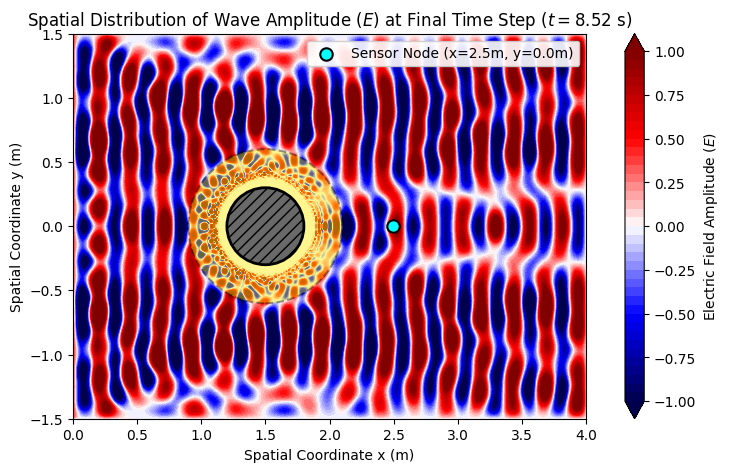

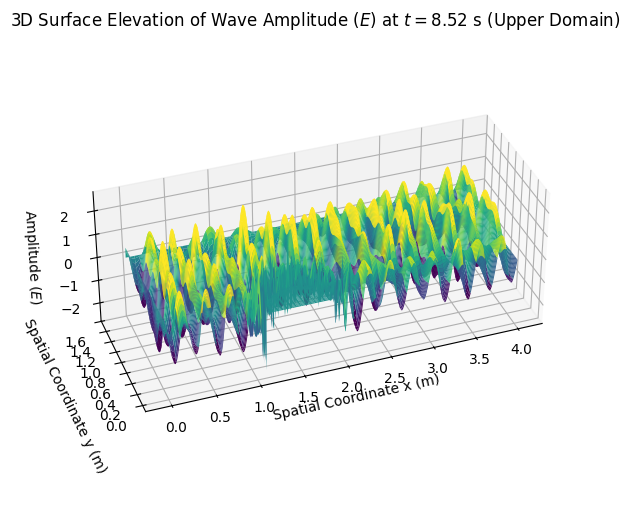

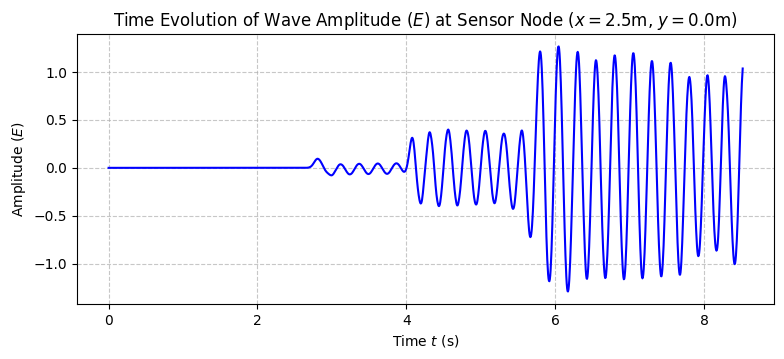

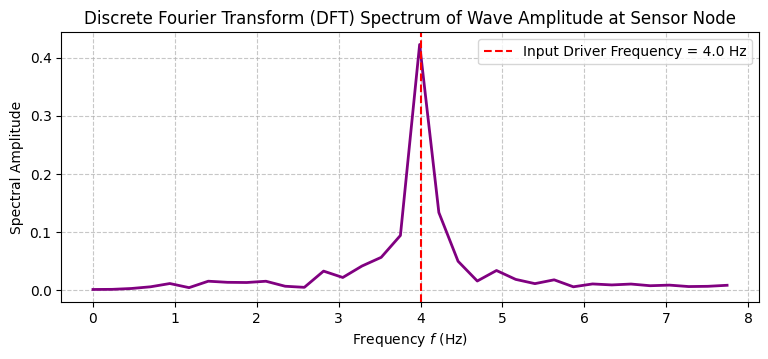

In [ ]:
# In this section I am showing/plotting the results

## Plot 1: 2D Contour Plot (Mirrored across symmetry line) ##
fig, ax = plt.subplots(figsize=(10, 5))

# Mirror the calculated top half to the bottom half to show the full physical effect
E_full = np.concatenate((E[-1, :, ::-1], E[-1, :, 1:]), axis=1)
Y_full = np.concatenate((-Y[:, ::-1], Y[:, 1:]), axis=1)
X_full = np.concatenate((X[:, ::-1], X[:, 1:]), axis=1)

# Lock contour levels to source amplitude (-1.0 to 1.0)
levels = np.linspace(-1.0, 1.0, 41)
cont = ax.contourf(X_full, Y_full, E_full, levels=levels, cmap='seismic', extend='both', zorder=1)

# Strict Z-ordering for the cloak visuals
circle_yellow = plt.Circle((cloak_x, cloak_y), R_outer, facecolor='yellow', alpha=0.4, 
                           edgecolor='black', linestyle='--', linewidth=1.5, zorder=10)
circle_grey = plt.Circle((cloak_x, cloak_y), R_inner, facecolor='dimgrey', 
                         edgecolor='black', hatch='///', linewidth=2.0, alpha=1.0, zorder=20)

ax.add_patch(circle_yellow)
ax.add_patch(circle_grey)

# Plot the sensor location marker
sensor_x_phys = node_x * dx 
ax.scatter(sensor_x_phys, 0.0, color='cyan', marker='o', s=80, edgecolors='black', 
           linewidths=1.5, zorder=30, label=f'Sensor Node (x={sensor_x_phys:.1f}m, y=0.0m)')

plt.colorbar(cont, label='Electric Field Amplitude ($E$)')
ax.legend(loc='upper right', framealpha=0.9)

plt.title(f'Spatial Distribution of Wave Amplitude ($E$) at Final Time Step ($t={Nt*dt:.2f}$ s)')
plt.xlabel('Spatial Coordinate x (m)')
plt.ylabel('Spatial Coordinate y (m)')

ax.set_aspect('equal') 

plt.show()


## Plot 2: 3D Surface Plot ##
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111, projection='3d')

# Render the surface
surf = ax.plot_surface(X, Y, E[-1, :, :], cmap='viridis', rcount=80, ccount=80, 
                       antialiased=True, vmin=-1.0, vmax=1.0)

# FIX: Dynamically set Z-limits to exactly contain the physical wave peak (~1.28)
z_max = np.max(np.abs(E[-1, :, :]))
ax.set_zlim(-z_max * 1.1, z_max * 1.1)

# FIX: Force the 3D bounding box to respect the physical aspect ratio of the domain
# The Z-axis is scaled down slightly (0.5) so the wave heights don't look artificially stretched
ax.set_box_aspect((Lx, Ly, 1.5)) 

# Adjust viewing angle for best visibility
ax.view_init(elev=35, azim=-110)

ax.set_title(f'3D Surface Elevation of Wave Amplitude ($E$) at $t={Nt*dt:.2f}$ s (Upper Domain)')
ax.set_xlabel('Spatial Coordinate x (m)')
ax.set_ylabel('Spatial Coordinate y (m)')
ax.set_zlabel('Amplitude ($E$)')
plt.show()


## Plot 3: 1D Line Plot (Time Series) ##
plt.figure(figsize=(9, 3.5))
plt.plot(t, signal, color='blue', linewidth=1.5)

plt.title(f'Time Evolution of Wave Amplitude ($E$) at Sensor Node ($x={sensor_x_phys:.1f}$m, $y=0.0$m)')
plt.xlabel('Time $t$ (s)')
plt.ylabel('Amplitude ($E$)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


## Plot 4: Fourier Frequency Spectrum (Add-on Topic) ##
plt.figure(figsize=(9, 3.5))
cutoff = int(8.0 * N_dft * dt) # Limit x-axis to 8 Hz for clear visibility
plt.plot(freqs[:cutoff], amplitude[:cutoff], color='purple', linewidth=2.0)


plt.title(f'Discrete Fourier Transform (DFT) Spectrum of Wave Amplitude at Sensor Node')
plt.xlabel('Frequency $f$ (Hz)')
plt.ylabel('Spectral Amplitude')
plt.axvline(x=SOURCE_FREQ, color='red', linestyle='--', 
            label=f'Input Driver Frequency = {SOURCE_FREQ} Hz')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [21]:
# In this section I am celebrating
print('CW done: I deserve a spectacular mark')

CW done: I deserve a spectacular mark
